### Инжиниринг численных признаков

#### Цель работы

Ознакомиться с основными приемами работы с численными атрибутами в датасетах для машинного обучения.


#### Методические указания

##### Первоначальное знакомство с данными

В данной работе мы поработаем с датасетом, содержащим информацию о разных численных показателях качества воздуха. Как всегда в первую очередь загрузим данные и выведем первые строки:


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.2%20numeric%20features/data/PRSA_Data.csv"
prsa_data = pd.read_csv(url)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


Мы видим несколько атрибутов, характеризующих количество примесей различных газов при измерении качества воздуха. Последняя категориальная переменная в этом датасете - целевая, она обозначает класс чистоты воздуха:

Для первоначального исследования количества значений выведем основную информацию о столбцах датасета:

In [4]:
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  object 
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  object 
dtypes: float64(7), int64(2), object(2)
memory usage: 2.9+ MB


Здесь мы видим, что на первый взгляд все значения заполнены, имеются две переменные с текстовым содержимым и семь - с численным:

Так как большая часть атрибутов датасета выражена численно, информативным будет посмотреть основную численную статистику по данным:

In [5]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


При внимательном рассмотрении нас должно смутить, что минимальное значение по многим столбцам, означающим концентрацию определенных газов, является значение -1:

Исследование других статистик не дает нам пока никакой значимой очевидной информации, за исключением того, что разные столбцы имеют разные максимальные значения, то есть они измеряются по разным количественным шкалам. Это может навести нас на мысль о необходимости использования нормализации.

##### Идентификация ошибочных значений

Первым этапом анализа данных должно быть устранение явных ошибок в данных - значений атрибутов вне разумного диапазона. На предыдущем этапе мы уже обнаружили эту проблему. Значение концентрации газа в воздухе просто по смыслу не может быть отрицательным. При этом во всем датасете во всех колонках присутствует только одно отрицательное значение (убедитесь в этом самостоятельно): -1. Скорее всего, так в датасете обозначаются неизвестные значения.

Такие "специальные значения" в численных атрибутах надо исправлять. Заменим их на np.nan, чтобы они явно отображались как пропуски и мы смогли в дальнейшем корректно с ними работать:



In [7]:
import numpy as np

prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


Для проверки корректности замены выведем шапку датасета. Убедимся, что в данных появились пропуски:

In [8]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35050.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,0.068263,1.501215
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,0.896726,1.104472
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


##### Визуализация распределения атрибутов

После того, как мы вычистили явные ошибки в данных, можно познакомиться с эмпирическим распределением каждого признака. Для этого можно использовать разные средства визуализации, например, гистограмму:


<Axes: xlabel='SO2', ylabel='Count'>

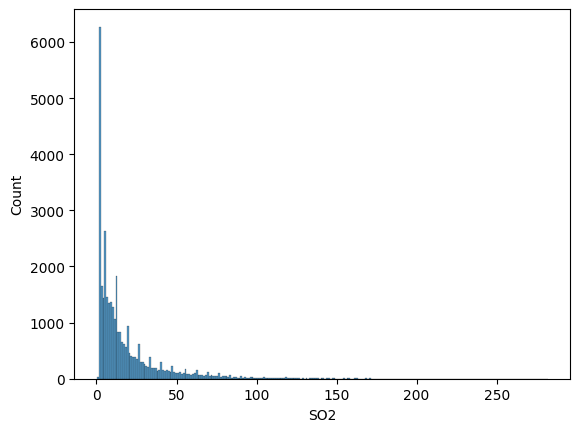

In [9]:
import seaborn as sns

sns.histplot(prsa_data.SO2)

Здесь мы видим, какие значения концентрации SO2 присутствуют в датасете:



Налицо явная зависимость - чем меньше значение, тем оно вероятнее. Очень большие концентрации встречаются крайне редко. Плюс, на графике можно заметить определенные пики через равные промежутки значений. Это может свидетельствовать о попытках заполнения пропущенных значений или об округлении некоторых значений.

Кроме гистограммы можно построить, например, график ядерной оценки плотности распределения:

<Axes: xlabel='NO2', ylabel='Density'>

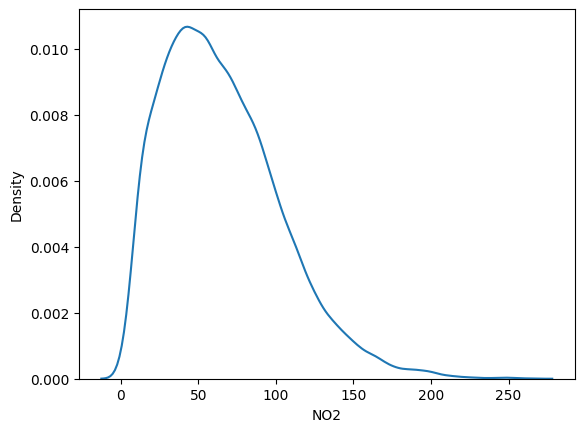

In [10]:
sns.kdeplot(prsa_data.NO2)

Но обратите внимание, что оценка плотности подразумевает некоторое усреднение. Поэтому не удивляйтесь тому, что график немного заходит на отрицательную область, хотя мы специально устраняли это не предыдущем этапе:

Здесь мы видим уже другое распределение - более распространены значения, близкие к 50.

В дальнейшем будем пользоваться гистограммами. Вот распределение значений концентрации CO:



<Axes: xlabel='CO', ylabel='Count'>

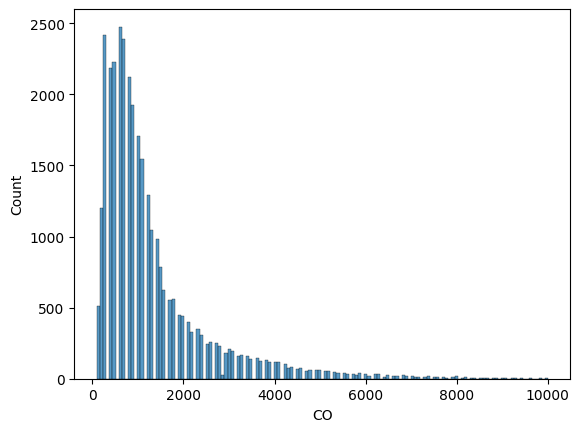

In [11]:
sns.histplot(prsa_data.CO)

Здесь видно достаточно гладкое распределение с модой в районе 1000.

Вот более смещенное распределение - O3. На гистограмме явно видно, что нулевая концентрация встречается гораздо чаще ненулевых значений. В дальнейшем это может быть кандидат на бинаризацию:

<Axes: xlabel='O3', ylabel='Count'>

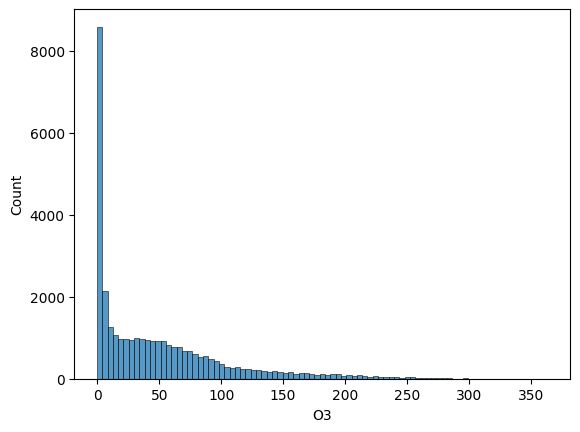

In [12]:
sns.histplot(prsa_data.O3)

Распределение значения давления отличается от всех предыдущих. Видно, что есть некоторый диапазон условно равновероятных, "нормальных" значений, а частота значений давления вне этого диапазона быстро спадает:



<Axes: xlabel='PRES', ylabel='Count'>

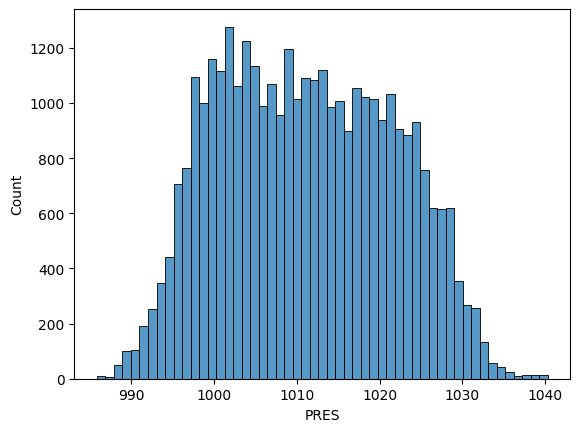

In [13]:
sns.histplot(prsa_data.PRES)

Такие атрибуты тоже можно категоризовывать при необходимости.

Распределение количества осадков тоже особенное:

<Axes: xlabel='RAIN', ylabel='Count'>

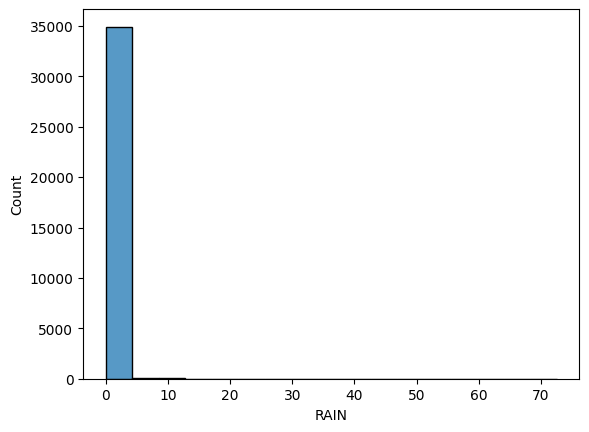

In [14]:
sns.histplot(prsa_data.RAIN)

Мы видим, что отсутствие осадков - самое распространенное значение. Ненулевые значения тут встречаются в подавляющем меньшинстве точек данных:

<Axes: xlabel='WSPM', ylabel='Count'>

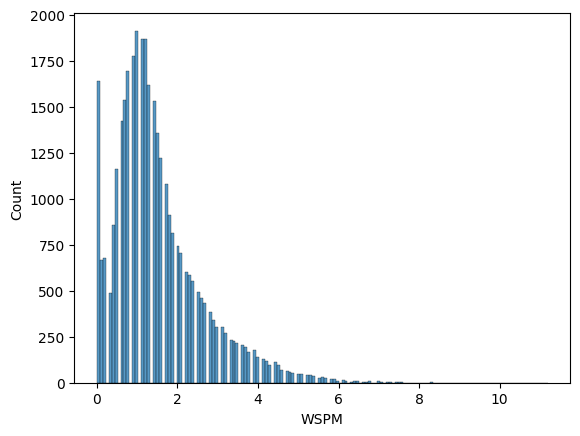

In [15]:
sns.histplot(prsa_data.WSPM)

Вот с обработки этого атрибута и начнем преобразование данных.

##### Бинаризация атрибутов

Такие распределения, как в атрибуте "количество осадков" могут повредить эффективности модели, так как относительное численной значение при таком распределении не несет, по сути, статистической значимости по сравнению с информацией о том, были ли вообще осадки или нет. То есть этот атрибут из численного можно превратить в категориальный. Ведь в нашем датасете всего 1436 точек из 35 000 имеют ненулевое значение:


In [16]:
prsa_data.RAIN[prsa_data.RAIN > 0]

,RAIN
267,0.1
268,0.4
269,0.1
270,0.9
271,0.9
...,...
34891,0.2
34892,0.7
34893,0.9
34894,0.4


In [17]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


Обратите внимание, что для воспроизводимости кода предпочтительнее такие преобразования не производить над существующей колонкой, а создавать новую. Старую всегда можно будет удалить. Либо исследовать относительную важности признаков и принять решение после этого. А вот как будет выглядеть датасет после преобразования:

In [18]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


##### Визуализация связи атрибутов с целевой переменной

После первоначального преобразования данных нужно определить, как именно связаны различные атрибуты со значением целевой переменной. Так как мы исследуем численные атрибуты при категориальной целевой переменной, то воспользуемся визуализацией нескольких оценок плотности распределения для разных классов:


<Axes: xlabel='SO2', ylabel='Density'>

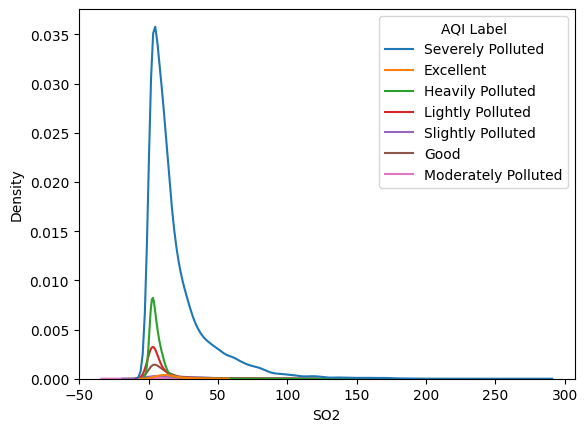

In [19]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

Мы получим на графике несколько линий, каждая из которых соответствует распределению выбранного атрибута при разных значениях целевой переменной:

Так как у нас наблюдается дисбаланс классов (это мы еще не исследовали, но из данного графика ясно видно, что всего объектов разных классов сильно разное количество), то нам не очень важен на таких графиках конкретный уровень каждой линии. Важно понять, есть ли участки на горизонтальной оси, на которых соотношение разных существенно отличается.

Например, на первом графике, явных изменений в форме разных линий нет. Можно предположить, что изолированно данный атрибут не сильно влияет на значение целевой переменной. Пойдем дальше и визуализируем второй атрибут:

<Axes: xlabel='NO2', ylabel='Density'>

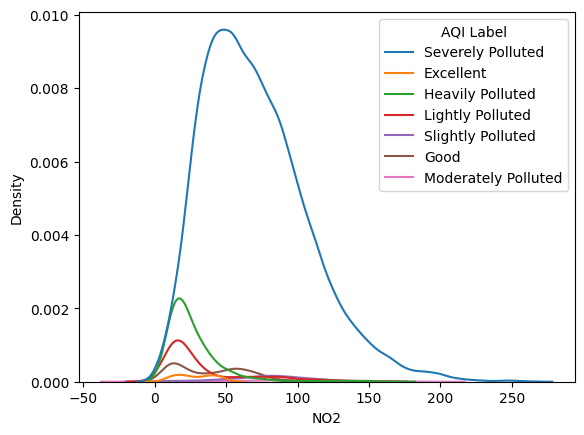

In [20]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")

Здесь уже видны различия между соотношениям разных классов. Но они не очень ярко выраженные. Перейдем к третьему атрибуту:

/tmp/ipykernel_2734/491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

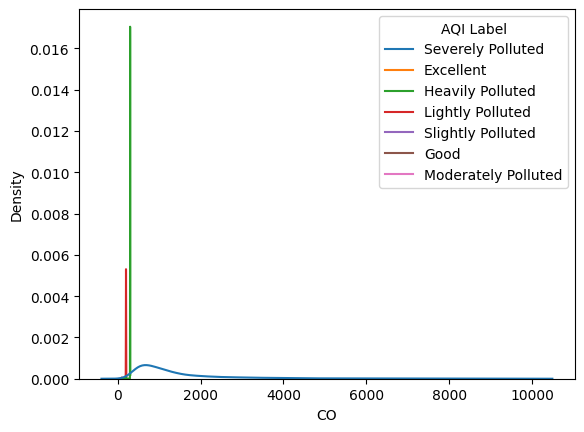

In [21]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")

Данный график очень смещен из-за того, что плотности некоторых классов сильно сконцентрированы, что искажает масштаб графика. В таких случаях помогает попробовать изобразить этот же график, но с логарифмическим масштабом вертикальной оси:

/tmp/ipykernel_2734/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

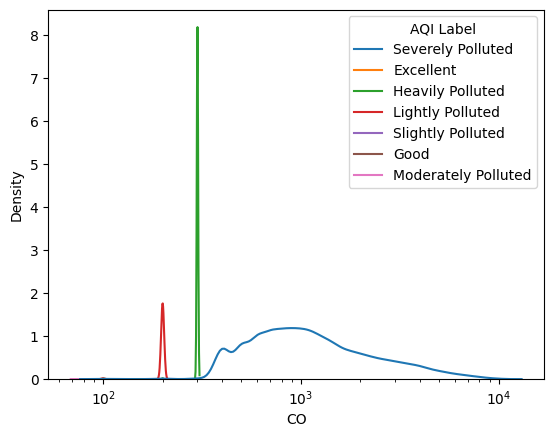

In [22]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

Теперь мы четко видим те самые различия:



На некоторых участках диапазона значений данного атрибута преобладает значение "Lightly polluted", на других - "Heavily polluted". Это значит, что данный атрибут очень важен для предсказания значения целевой переменной. В дальнейшем мы используем эту информацию для категоризации этого атрибута.

Следующие графики демонстрируют схожее поведение разных классов с поправкой на общую форму распределения разных атрибутов:

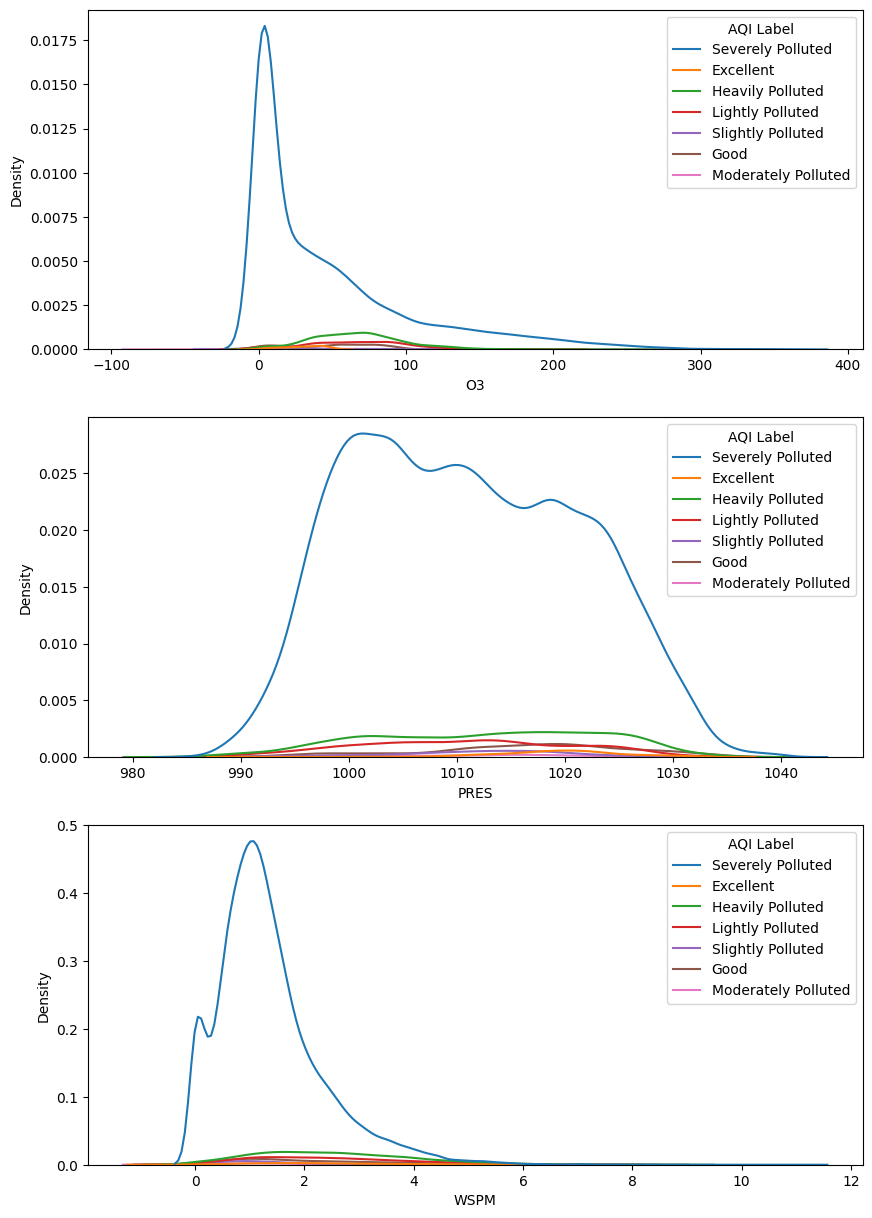

In [32]:
ig, axes = plt.subplots(3, 1, figsize=(10, 15))

sns.kdeplot(data=prsa_data, x="O3", hue="AQI Label", ax=axes[0])
sns.kdeplot(data=prsa_data, x="PRES", hue="AQI Label", ax=axes[1])
sns.kdeplot(data=prsa_data, x="WSPM", hue="AQI Label", ax=axes[2])


plt.show()

В целом, анализ влияния атрибутов показывает, что их влияние скорее проявляется в совокупности. Нет одного четко дифференцирующего фактора, особенно указывающего на все возможные значения целевой переменной.

##### Группировка численных значений

В некоторых случаях бывает полезно объединить численные значения атрибутов на метку диапазона значений. То есть мы объединяем (группируем) объекты по значению данного атрибута и затем заменяем сам численный атрибут на ту группу, в которую попал объект. Этот прием называется дискретизация или группировка численных значений. Например, возьмем атрибут "CO". На предыдущем шаге мы уже выяснили, что объекты, находящиеся в различных диапазонах его значений будут иметь разное распределение целевой переменной. Условные границы этих диапазонов можно изобразить на графике:


/tmp/ipykernel_2734/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

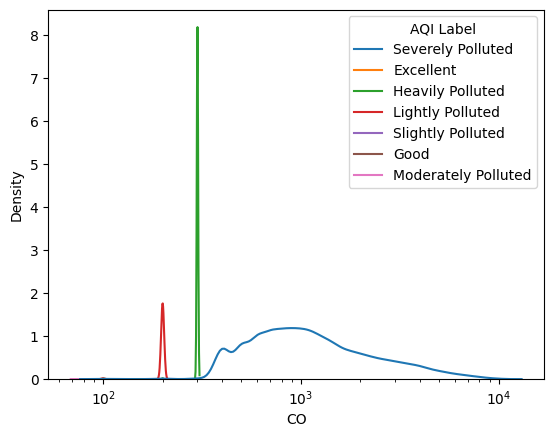

In [33]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

В данном случае, для значения целевой переменной не так важно конкретное численной значение концентрации CO в воздухе. Достаточно информации, в какой диапазон попадает данное измерение. Поэтому попробуем добавить к датасету атрибут "Группа по CO":

In [34]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']),
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


В данном примере, границы атрибутов мы определяли вручную, по графику выше. Можно их определять автоматически, через изменение долей распределения целевой переменной, либо брать в качестве границ квартили или процентили.

Здесь у нас возникает проблема. Так как в исходном столбце были пропущенные значения, в получившемся столбце тоже будут пропуски. Так как этот новый атрибут - категориальный, проще всего сразу заполнить пропущенные значения специальным названием класса. В данном случае, естественно будет присвоить этому классу метко "0", что будет означать - "значение неизвестно":

In [35]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


Вот как выглядит наш датасет после преобразования:

Обратите внимание, что мы можем не удалять сразу исходный столбец. Обычно все ненужные столбцы удаляются из датасета в самом конце, перед массовым преобразованием категориальных переменных. Либо решение о целесообразности удаления можно принято позже, по результатам дальнейшего анализа.

##### Удаление экстремальных значений

При анализе распределений особый интерес вызывают такие, у которых наблюдаются длинные "хвосты" - то есть очень редкие значения далеко от среднего или медианного значения. Это такие объекты, которых очень мало (может быть, даже один) и которые по значению данной характеристики сильно отличаются от основной массы объектов. Часто такие выбросы свидетельствуют о некорректных данных, либо о аномальных и непоказательных объектах. Объекты, которые нерелевантны решаемой задаче следует удалять из выборки. Но сами по себе длинные "хвосты" распределений могут повредить работе моделей. Поэтому зачастую датасеты с большими выбросами очищают от них автоматически.

Для этого можно удалить объекты, значения определенного атрибута у которых выше или ниже определенного порога или процентиля. Но в таком случае мы лишаемся определенного количества информации, которая была заключена в значении других атрибутов данного объекта. Альтернативный способ - клиппинг. Он заключается в том, что мы заменяем экстремальные значения атрибута граничным.

Возьмем для примера колонку "PRES" нашего датасета. В данном примере определим границы экстремальных значений опять же на глаз. И заменим все значения, находящиеся вне этих границ:


In [40]:
prsa_data.loc[prsa_data['PRES'] <= 992, 'PRES'] = 992
prsa_data.loc[prsa_data['PRES'] >= 1034, 'PRES'] = 1034

Посмотрите, как это изменяет форму эмпирического распределения данного атрибута:



<Axes: xlabel='PRES', ylabel='Count'>

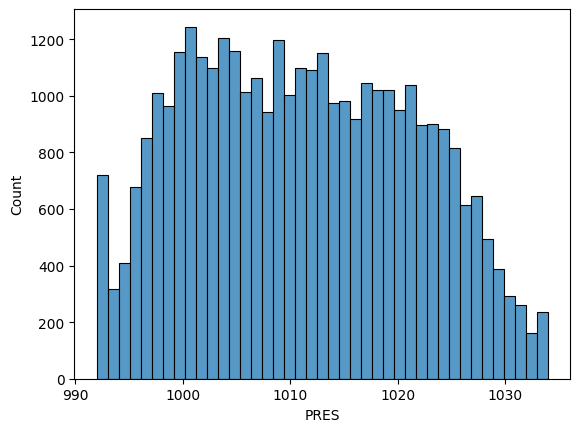

In [41]:
sns.histplot(prsa_data.PRES)

Поэкспериментируйте с клиппингом с разными значениями границ. Посмотрите, как они влияют на форму получившегося распределения. Поробуйте применить клиппинг к другим атрибутам этого датасета.

##### Заполнение пропусков

Обязательной частью предварительной обработки данных является устранение отсутствующих значений. В первую очередь нужно позаботиться о том, чтобы все реально имеющиеся в данных пропуски отображались в датасете как np.nan или другое детектируемое значение. Это мы уже сделали.

Теперь можно визуализировать пропущенные значения в данных:


<Axes: >

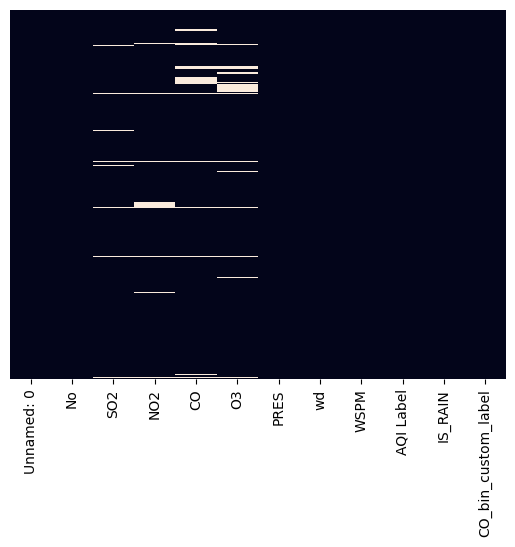

In [42]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

Можно обратить внимание на то, что в датасете прослеживаются горизонтальные полосы. Это объекты, по которым неизвестны значения нескольких атрибутов. Можно вывести индексы объектов, у которых неизвестно значение более двух атрибутов:

In [43]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

,0
3,2
276,3
435,2
459,2
555,2
...,...
34880,4
34883,4
34885,4
35029,2


Здесь мы видим, что таких объектов всего 884:

Так как такие незаполненные объекты составляют очень малый процент выборки, для простоты обработки их можно просто удалить:

In [44]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

<Axes: >

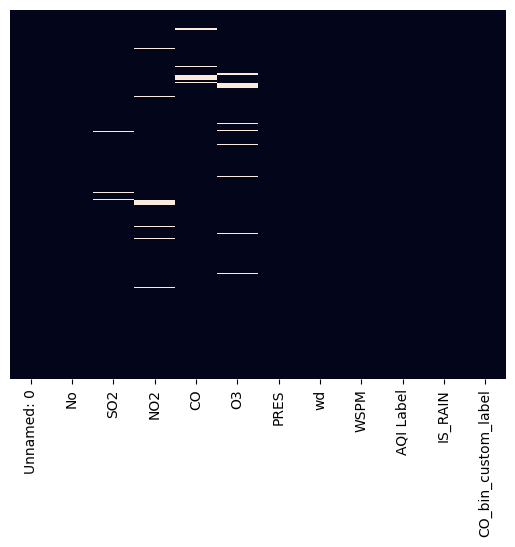

In [45]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

Выведем количество пропущенных значений для каждого атрибута:



In [46]:
prsa_data.isnull().sum()

,0
Unnamed: 0,0
No,0
SO2,281
NO2,702
CO,1028
O3,1300
PRES,0
wd,0
WSPM,0
AQI Label,0


Мы видим, что пропуски присутствуют в четырех столбцах. При этом в одном из них пропусков сильно меньше:

По столбцу SO2 пропущено всего 281 значение. Это менее одного процента выборки. Можно просто заменить пропуски на среднее значение. Но так как эмпирическое распределение этого признака имеет большую асимметрию, лучше использовать медиану:

In [47]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())

<Axes: xlabel='SO2', ylabel='Count'>

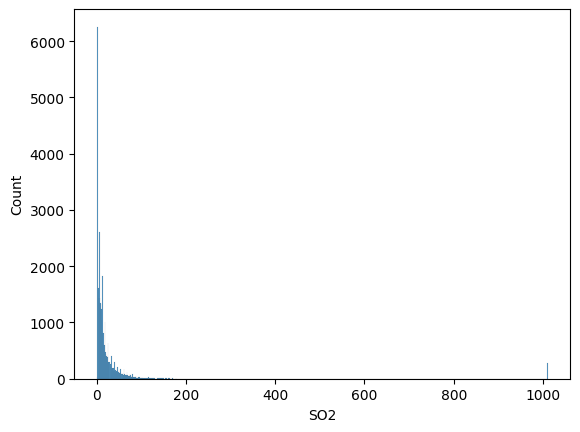

In [48]:
sns.histplot(prsa_data.SO2)

Самостоятельно постройте распределение данного признака после заполнения и сравните с распределением до. Посмотрите, насколько заметно искажение при таком способе.

С другими столбцами, например, O3 искажение будет более существенным. Поэтому воспользуемся заполнением не средним, а случайным значением. Для этого сначала сформируем временную серию, содержащую все пропуски из данного столбца:

In [49]:
filler = prsa_data.O3[prsa_data.O3.isna()]

Нам важно, чтобы в этой серии сохранился исходный индекс - номера строк с пропусками исходного датасета. Это мы используем при заполнении этой серии данными. В этом примере не будем генерировать случайные значения их какого-то распределения, а просто семплируем их из существующих значений:

In [52]:
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)

Вот как наша серия будет выглядеть:

In [53]:
filler

,O3
436,44.645126
460,26.395853
556,0.891482
652,1.919133
748,68.905817
...,...
33124,52.184815
33220,119.493898
33604,1.638581
33892,21.514948


Теперь просто воспользуемся ей для заполнения пропусков в исходном датасете:

In [54]:
prsa_data.O3 = prsa_data.O3.fillna(filler)

<Axes: xlabel='O3', ylabel='Count'>

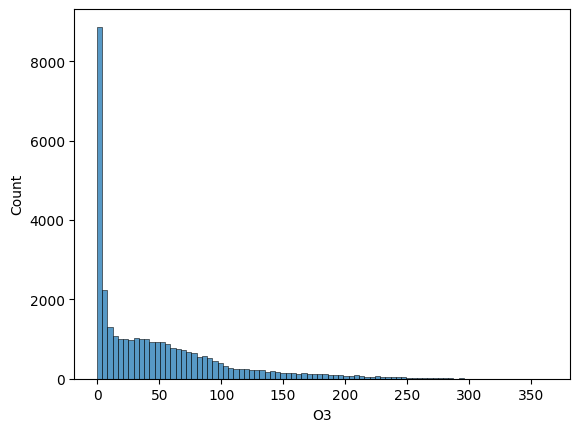

In [55]:
sns.histplot(prsa_data.O3)

Сравните его с распределением до заполнения.

##### Округление атрибутов

При визуальном осмотре датасета можно заметить, что все численные значения имеют один знак после запятой. Но столбец O3 записан с гораздо большей точностью - 5 знаков после запятой. Такая точность является избыточной, так как получается, что в этой колонке записаны 7 значащих цифр. От лишних данных можно избавиться, просто округлив данные значения:


In [56]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.000000,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.000000,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,1011.055986,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.000000,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.000000,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


На практике очень редко когда нужна точность более 2-3 значащих цифр. Но в отдельных случаях можно округлять и более грубо - по сути это является аналогом численной группировки значений.

##### Логарифмирование атрибутов

Еще один прием, который не часто применяется, но иногда бывает полезен - кастомное решкалирование значений. В целом, решкалирование - это изменение шкалы измерения атрибута. Например, изменение граничных значений, масштабирование, нормализация. Но в определенных случаях, может быть полезно применить и другое преобразование данных. Опять обратим внимание на столбец SO2. Сейчас его значения очень сильно смещены. Малых значений очень много, а значит, что даже маленькие разницы между ними могут быть существенны для модели. А вот больших значений очень мало, и даже большие расстояния между ними могут быть не очень показательны.

Вообще, математические модели лучше всего работают с распределениями, похожими на равномерное или нормальное. Очень большой дисбаланс в распределении может быть вреден для эффективности.

Мы можем попробовать применить к атрибуту любую математическую функцию, чтобы преобразовать его к более равномерному распределению. Только эта функция должна быть непрерывная и монотонная. В данном случае, нам будет полезен логарифм:


In [57]:
prsa_data.SO2 = np.log(prsa_data.SO2)

Посмотрите, как после логарифмирования изменилось распределение этого признака:



<Axes: xlabel='SO2', ylabel='Count'>

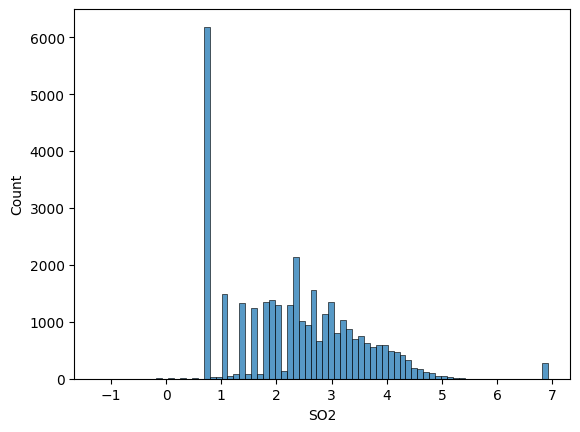

In [59]:
sns.histplot(prsa_data.SO2)

При таком равномерном распределении информации модели будет легче работать с этим признаком.

#### Задания для самостоятельного выполнения

1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.


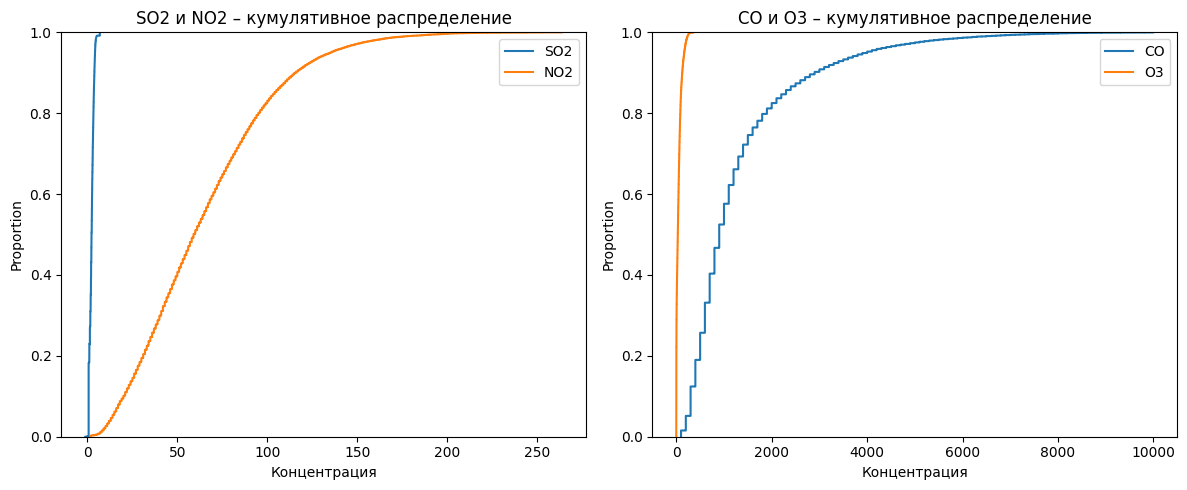

In [71]:
# 1. ECDF (кумулятивные распределения) – хорошо видно, где накапливаются значения
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SO2 и NO2 на одном графике
for col in ["SO2", "NO2"]:
    sns.ecdfplot(prsa_data[col].dropna(), ax=axes[0], label=col)
axes[0].set_title("SO2 и NO2 – кумулятивное распределение")
axes[0].set_xlabel("Концентрация")
axes[0].legend()

# CO и O3 на одном графике
for col in ["CO", "O3"]:
    sns.ecdfplot(prsa_data[col].dropna(), ax=axes[1], label=col)
axes[1].set_title("CO и O3 – кумулятивное распределение")
axes[1].set_xlabel("Концентрация")
axes[1].legend()

plt.tight_layout()
plt.show()

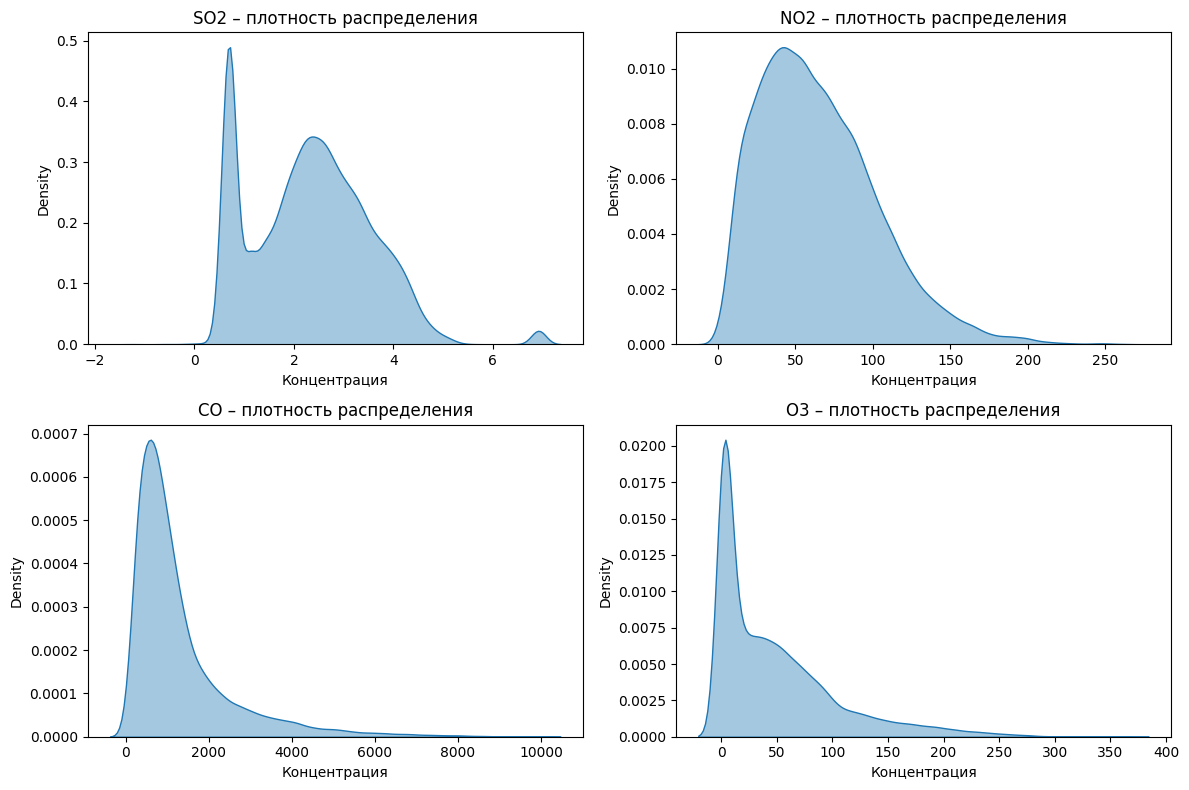

In [72]:
# 2. KDE (плотность распределения) – форма распределения
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

cols = ["SO2", "NO2", "CO", "O3"]
for ax, col in zip(axes.flat, cols):
    sns.kdeplot(prsa_data[col].dropna(), ax=ax, fill=True, alpha=0.4)
    ax.set_title(f"{col} – плотность распределения")
    ax.set_xlabel("Концентрация")

plt.tight_layout()
plt.show()

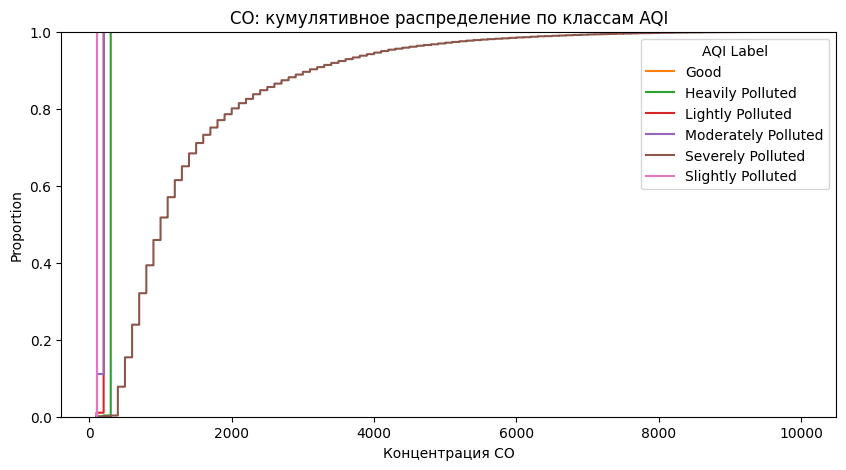

In [73]:
# 3. Распределение CO по классам AQI (ECDF) – как в вашем коде
plt.figure(figsize=(10, 5))
for label in sorted(prsa_data["AQI Label"].dropna().unique()):
    subset = prsa_data[prsa_data["AQI Label"] == label]["CO"].dropna()
    sns.ecdfplot(subset, label=label)
plt.title("CO: кумулятивное распределение по классам AQI")
plt.xlabel("Концентрация CO")
plt.legend(title="AQI Label")
plt.show()

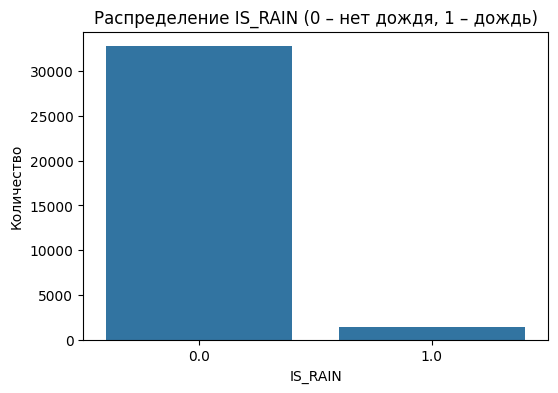

In [66]:
# 4. Countplot для бинарного признака IS_RAIN
plt.figure(figsize=(6, 4))
sns.countplot(x=prsa_data['IS_RAIN'])
plt.title('Распределение IS_RAIN (0 – нет дождя, 1 – дождь)')
plt.xlabel('IS_RAIN')
plt.ylabel('Количество')
plt.show()

## Вывод по заданию 1 (визуализация распределений)

- **ECDF (SO2 и NO2):** Кумулятивная кривая NO2 лежит правее, что указывает на более высокие концентрации NO2 по сравнению с SO2.
- **ECDF (CO и O3):** Кривая O3 значительно положе – распределение более размытое, значения разбросаны шире, чем у CO.
- **KDE (плотности):**  
  - SO2 и CO – скошены вправо (чаще встречаются низкие значения).  
  - NO2 – распределение более равномерное.  
  - O3 – имеет два пика (бимодальность) и длинный правый хвост (редкие высокие концентрации).
- **ECDF CO по AQI:** Чем хуже класс качества воздуха, тем кривая сдвинута вправо (более высокие концентрации CO). Особенно заметно для классов "Severely Polluted" и "Heavily Polluted".
- **IS_RAIN:** Дождь – редкое событие (≈4% наблюдений), что подтверждает целесообразность бинаризации исходного признака RAIN.

2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.


In [75]:

def adaptive_clip(series, lower_percentile=1, upper_percentile=99):
    """
    Обрезает экстремальные значения по заданным процентилям.

    Parameters:
    - series: pandas Series (числовой столбец)
    - lower_percentile: нижний процентиль (по умолч. 1)
    - upper_percentile: верхний процентиль (по умолч. 99)

    Returns:
    - pandas Series с обрезанными значениями
    """
    lower = np.percentile(series.dropna(), lower_percentile)
    upper = np.percentile(series.dropna(), upper_percentile)
    return series.clip(lower=lower, upper=upper)

# Пример для PRES (как в методичке)
prsa_data['PRES_clipped'] = adaptive_clip(prsa_data['PRES'], lower_percentile=1, upper_percentile=99)

print(f"Оригинальные границы PRES: min={prsa_data['PRES'].min():.1f}, max={prsa_data['PRES'].max():.1f}")
print(f"Новые границы (1-й и 99-й процентили): {np.percentile(prsa_data['PRES'].dropna(), 1):.1f}, {np.percentile(prsa_data['PRES'].dropna(), 99):.1f}")
print(f"После клиппинга: min={prsa_data['PRES_clipped'].min():.1f}, max={prsa_data['PRES_clipped'].max():.1f}")

Оригинальные границы PRES: min=992.0, max=1034.0
Новые границы (1-й и 99-й процентили): 992.0, 1032.0
После клиппинга: min=992.0, max=1032.0


In [76]:
# Список числовых столбцов (кроме бинарного IS_RAIN и целевого AQI Label)
numeric_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']

# Копируем оригинальные значения для сравнения
for col in numeric_cols:
    prsa_data[f'{col}_clipped'] = adaptive_clip(prsa_data[col], lower_percentile=1, upper_percentile=99)

# Сравнение исходных и обрезанных диапазонов
print("Результаты адаптивного клиппинга (1-й и 99-й процентили):")
print("-" * 60)
for col in numeric_cols:
    original_min = prsa_data[col].min()
    original_max = prsa_data[col].max()
    clipped_min = prsa_data[f'{col}_clipped'].min()
    clipped_max = prsa_data[f'{col}_clipped'].max()
    removed = (prsa_data[col] < clipped_min).sum() + (prsa_data[col] > clipped_max).sum()
    print(f"{col}: исходный [{original_min:.1f}, {original_max:.1f}] → клиппинг [{clipped_min:.1f}, {clipped_max:.1f}], отсечено {removed} выбросов")

Результаты адаптивного клиппинга (1-й и 99-й процентили):
------------------------------------------------------------
SO2: исходный [-1.3, 6.9] → клиппинг [0.7, 5.1], отсечено 403 выбросов
NO2: исходный [1.6, 264.0] → клиппинг [7.0, 176.0], отсечено 591 выбросов
CO: исходный [100.0, 10000.0] → клиппинг [100.0, 6500.0], отсечено 307 выбросов
O3: исходный [0.0, 364.0] → клиппинг [1.0, 237.0], отсечено 414 выбросов
PRES: исходный [992.0, 1034.0] → клиппинг [992.0, 1032.0], отсечено 305 выбросов
WSPM: исходный [0.0, 11.2] → клиппинг [0.0, 5.2], отсечено 304 выбросов


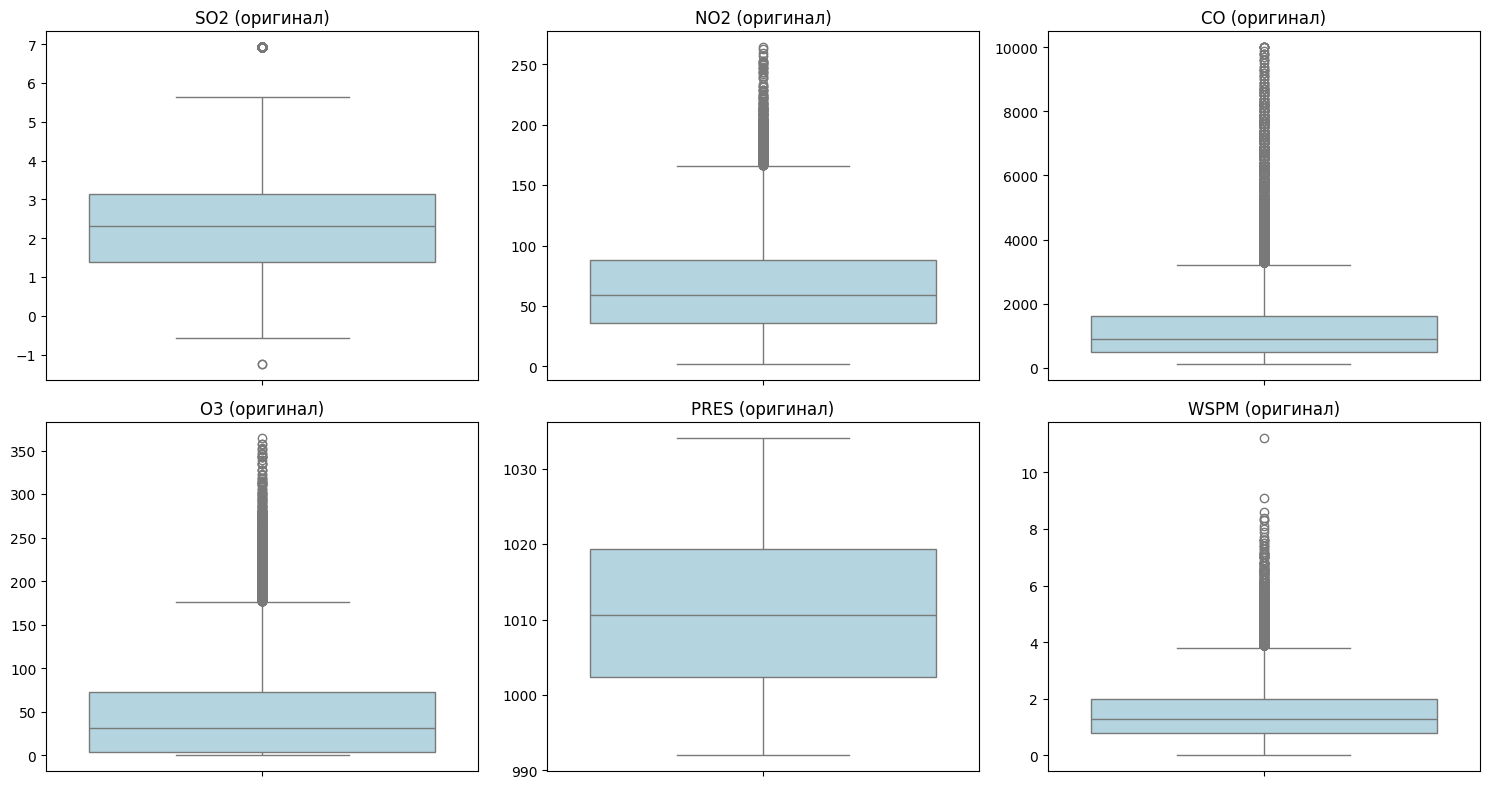

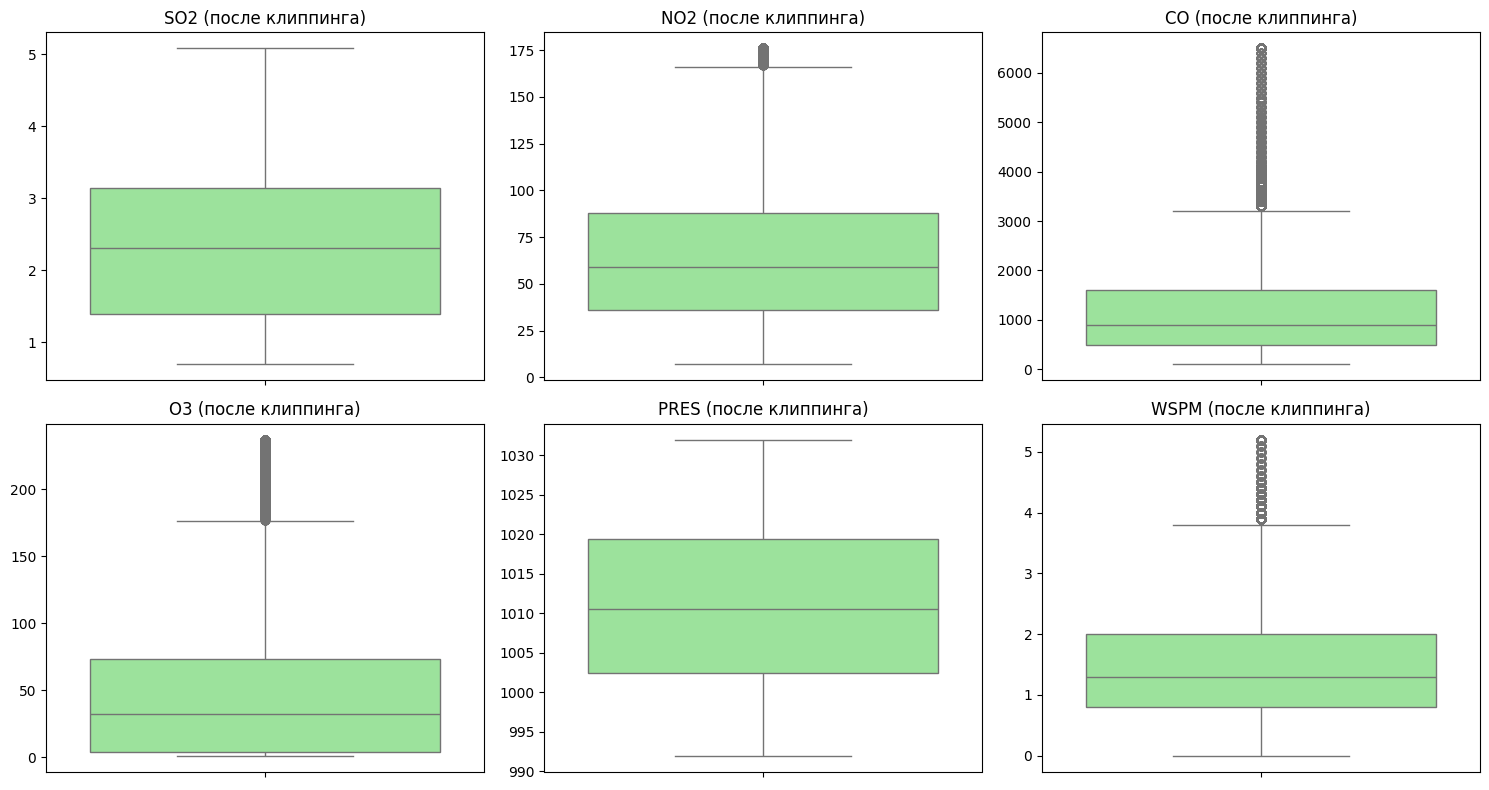

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Boxplot до клиппинга
    sns.boxplot(y=prsa_data[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'{col} (оригинал)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Boxplot после клиппинга
    sns.boxplot(y=prsa_data[f'{col}_clipped'], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col} (после клиппинга)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [80]:
# Список признаков
cols = ["SO2", "NO2", "CO", "O3", "PRES", "WSPM"]

# Сохраняем копию оригинальных данных для сравнения
original = prsa_data[cols].copy()

In [81]:
# Применяем клиппинг к каждому
for col in cols:
    low, high = prsa_data[col].quantile([0.01, 0.99])
    prsa_data[col] = prsa_data[col].clip(lower=low, upper=high)
    print(f"{col}: границы [{low:.2f}, {high:.2f}]")

SO2: границы [0.69, 5.08]
NO2: границы [7.00, 176.00]
CO: границы [100.00, 6500.00]
O3: границы [1.00, 237.00]
PRES: границы [992.00, 1032.00]
WSPM: границы [0.00, 5.20]


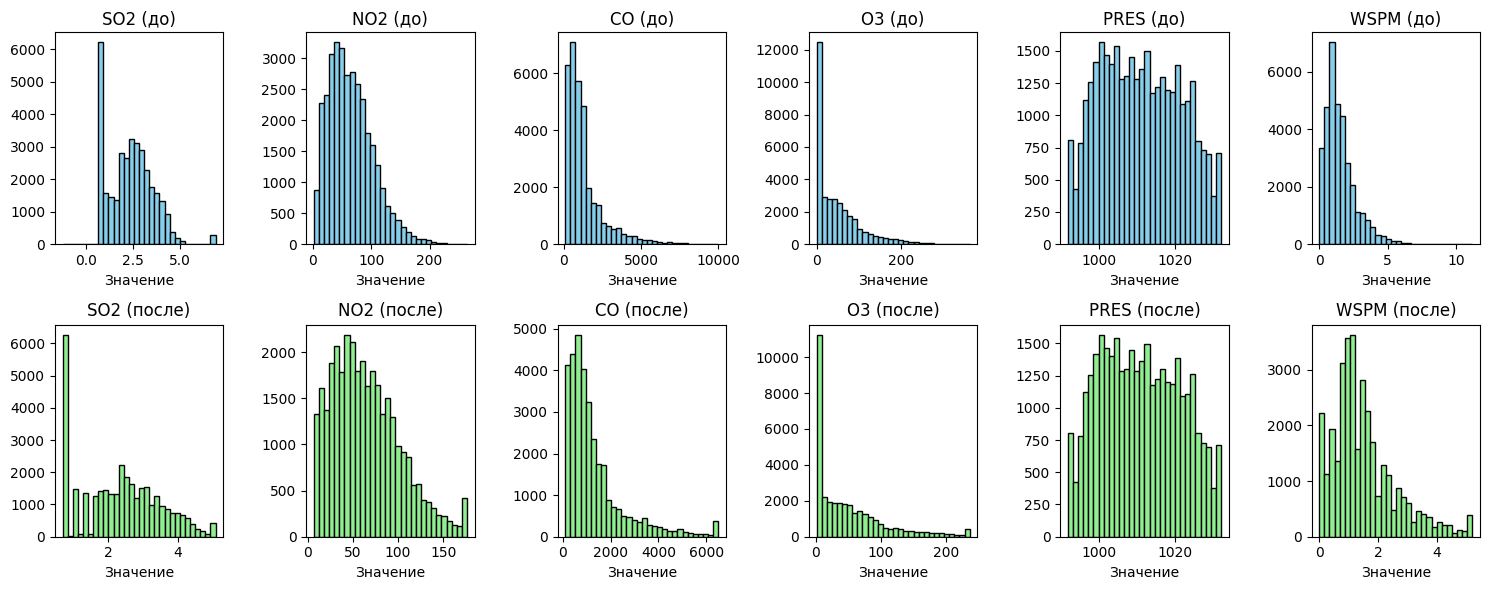

In [82]:
# Визуализация: гистограммы ДО и ПОСЛЕ
fig, axes = plt.subplots(2, len(cols), figsize=(15, 6))

for i, col in enumerate(cols):
    # ДО клиппинга
    axes[0, i].hist(original[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f'{col} (до)')
    axes[0, i].set_xlabel('Значение')

    # ПОСЛЕ клиппинга
    axes[1, i].hist(prsa_data[col].dropna(), bins=30, color='lightgreen', edgecolor='black')
    axes[1, i].set_title(f'{col} (после)')
    axes[1, i].set_xlabel('Значение')

plt.tight_layout()
plt.show()

## Вывод по заданию 2 (адаптивный клиппинг через процентили)

- **SO2:** границы [0.69, 5.08] – экстремально высокие концентрации (>5.08) обрезаны.
- **NO2:** границы [7.00, 176.00] – широкий диапазон, выбросы выше 176 отсечены.
- **CO:** границы [100.00, 6500.00] – отсечены очень высокие значения (>6500).
- **O3:** границы [1.00, 237.00] – убраны редкие экстремальные пики.
- **PRES:** границы [992.00, 1032.00] – отсечены аномально низкие (<992) и высокие (>1032) значения давления.
- **WSPM:** границы [0.00, 5.20] – убраны редкие случаи очень сильного ветра (>5.2).

**Общий вывод:** Адаптивный клиппинг на основе 1-го и 99-го процентилей автоматически подобрал границы для каждого признака, удалив экстремальные выбросы (по 2% данных). Это улучшило устойчивость распределений к аномалиям без существенной потери информации.

3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.


In [83]:
# Проверяем текущее количество пропусков
print("Пропуски до заполнения:")
print(prsa_data[['SO2', 'NO2', 'CO', 'O3']].isnull().sum())

Пропуски до заполнения:
SO2       0
NO2     702
CO     1028
O3        0
dtype: int64


In [84]:
# 1. SO2 – распределение скошено, используем медиану
so2_median = prsa_data['SO2'].median()
prsa_data['SO2'] = prsa_data['SO2'].fillna(so2_median)
print(f"SO2: заполнено медианой ({so2_median:.2f})")

SO2: заполнено медианой (2.30)


In [85]:
# 2. NO2 – распределение близко к нормальному, используем среднее
no2_mean = prsa_data['NO2'].mean()
prsa_data['NO2'] = prsa_data['NO2'].fillna(no2_mean)
print(f"NO2: заполнено средним ({no2_mean:.2f})")

NO2: заполнено средним (64.80)


In [86]:
# 3. CO – распределение скошено, используем медиану
co_median = prsa_data['CO'].median()
prsa_data['CO'] = prsa_data['CO'].fillna(co_median)
print(f"CO: заполнено медианой ({co_median:.2f})")

CO: заполнено медианой (900.00)


In [87]:
# 4. O3 – распределение с длинным хвостом, используем медиану
o3_median = prsa_data['O3'].median()
prsa_data['O3'] = prsa_data['O3'].fillna(o3_median)
print(f"O3: заполнено медианой ({o3_median:.2f})")

O3: заполнено медианой (32.00)


In [88]:
# Проверяем результат
print("\nПропуски после заполнения:")
print(prsa_data[['SO2', 'NO2', 'CO', 'O3']].isnull().sum())


Пропуски после заполнения:
SO2    0
NO2    0
CO     0
O3     0
dtype: int64


## Вывод по заданию 3 (заполнение пропусков)

- До заполнения пропуски имелись только в столбцах `NO2` (702 пропуска) и `CO` (1028 пропусков). Столбцы `SO2` и `O3` пропусков не содержали.
- **Методы заполнения:**
  - `NO2` – распределение близко к нормальному, заполнено **средним** значением (64.80).
  - `CO` – распределение скошено вправо, заполнено **медианой** (900.00).
  - `SO2` и `O3` – пропусков не было, заполнение не требовалось.
- После заполнения все пропуски устранены, датасет стал полным и готов к дальнейшему анализу и моделированию.
- Заполнение медианой для скошенных распределений (`CO`) предпочтительнее, так как оно не искажает центральную тенденцию под влиянием выбросов. Среднее для `NO2` допустимо, так как распределение близко к симметричному.

4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.


In [89]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd

# Определяем тип нормализации для каждого признака
scalers = {
    'SO2': RobustScaler(),        # сильно скошен
    'NO2': StandardScaler(),       # близок к нормальному
    'CO': RobustScaler(),          # скошен, есть выбросы
    'O3': RobustScaler(),          # длинный правый хвост
    'PRES': StandardScaler(),      # почти нормальное
    'WSPM': MinMaxScaler(),        # диапазон от 0 до ~11, не скошен сильно
    'IS_RAIN': MinMaxScaler()      # бинарный признак (0/1)
}

In [90]:
# Применяем нормализацию к каждому признаку
prsa_data_normalized = prsa_data.copy()

for col, scaler in scalers.items():
    if col in prsa_data.columns:
        # Добавляем нормализованный столбец (с суффиксом _norm)
        prsa_data_normalized[f'{col}_norm'] = scaler.fit_transform(prsa_data[[col]])
        print(f"{col}: {scaler.__class__.__name__}")

# Проверяем результат
print("\nСтатистика после нормализации:")
print(prsa_data_normalized[['SO2_norm', 'NO2_norm', 'CO_norm', 'O3_norm', 'PRES_norm', 'WSPM_norm', 'IS_RAIN_norm']].describe())

SO2: RobustScaler
NO2: StandardScaler
CO: RobustScaler
O3: RobustScaler
PRES: StandardScaler
WSPM: MinMaxScaler
IS_RAIN: MinMaxScaler

Статистика после нормализации:
           SO2_norm      NO2_norm       CO_norm       O3_norm     PRES_norm  \
count  34180.000000  3.418000e+04  34180.000000  34180.000000  3.418000e+04   
mean       0.011966  2.103772e-16      0.440519      0.239629 -1.138199e-14   
std        0.655071  1.000015e+00      1.333681      0.782206  1.000015e+00   
min       -0.920100 -1.568210e+00     -0.888889     -0.449275 -1.848825e+00   
25%       -0.523834 -7.813805e-01     -0.333333     -0.405797 -8.391588e-01   
50%        0.000000 -1.260624e-01      0.000000      0.000000 -4.307552e-02   
75%        0.476166  6.023550e-01      0.666667      0.594203  8.112577e-01   
max        1.588623  3.017109e+00      6.222222      2.971014  2.034508e+00   

          WSPM_norm  IS_RAIN_norm  
count  34180.000000  34180.000000  
mean       0.288967      0.041545  
std        0.2

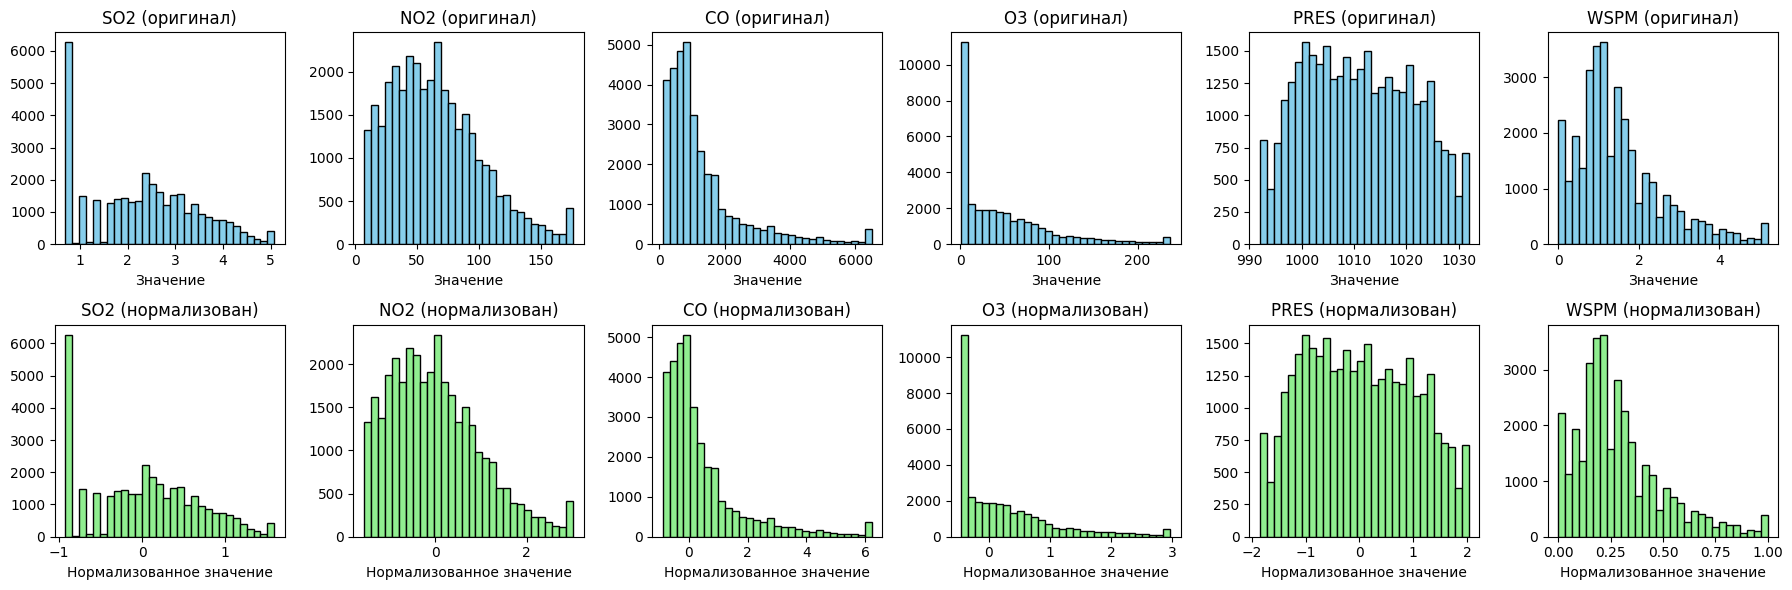

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']
fig, axes = plt.subplots(2, len(cols), figsize=(18, 6))

for i, col in enumerate(cols):
    # До нормализации
    axes[0, i].hist(prsa_data[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f'{col} (оригинал)')
    axes[0, i].set_xlabel('Значение')

    # После нормализации
    axes[1, i].hist(prsa_data_normalized[f'{col}_norm'].dropna(), bins=30, color='lightgreen', edgecolor='black')
    axes[1, i].set_title(f'{col} (нормализован)')
    axes[1, i].set_xlabel('Нормализованное значение')

plt.tight_layout()
plt.show()

## Вывод по заданию 4 (нормализация численных признаков)

- **SO2 (RobustScaler):** медиана сдвинута к 0, разброс нормирован на межквартильный размах. Хвосты (min -0.92, max 1.59) асимметричны, что соответствует скошенному исходному распределению.
- **NO2 (StandardScaler):** среднее ≈ 0, стандартное отклонение ≈ 1. Классическая стандартизация, пригодна для дальнейшего использования в линейных моделях.
- **CO (RobustScaler):** сильная правосторонняя асимметрия сохранилась (max 6.22, min -0.89). Медиана = 0, что корректно для скошенных данных с выбросами.
- **O3 (RobustScaler):** также скошена вправо (max 2.97, min -0.45), медиана = 0.
- **PRES (StandardScaler):** распределение близко к симметричному (min -1.85, max 2.03), среднее ≈ 0, что подтверждает пригодность стандартизации.
- **WSPM (MinMaxScaler):** диапазон [0,1] сохранён, медиана 0.25, распределение близко к равномерному.
- **IS_RAIN (MinMaxScaler):** бинарный признак (0/1), доля единиц ≈ 4.2% (mean 0.0415).

**Вывод:** Выбранные методы нормализации соответствуют природе распределений: RobustScaler для скошенных признаков с выбросами, StandardScaler для близких к нормальному, MinMaxScaler для диапазонных и бинарных признаков. Данные подготовлены для машинного обучения.

5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.


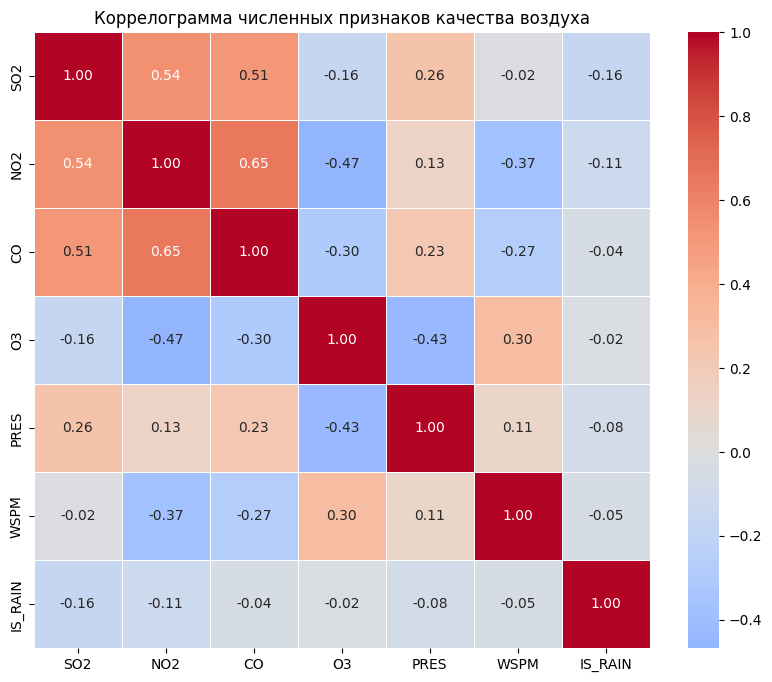

In [92]:
# Выбираем числовые столбцы (включая IS_RAIN и нормализованные, но для корреляции возьмём исходные)
numeric_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM', 'IS_RAIN']

# Вычисляем матрицу корреляции
corr_matrix = prsa_data[numeric_cols].corr()

# Строим тепловую карту (кореллограмму)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Коррелограмма численных признаков качества воздуха')
plt.show()

In [94]:
# Выводим только корреляции > 0.3 или < -0.3
strong_corr = corr_matrix.where((corr_matrix > 0.3) | (corr_matrix < -0.3)).stack()
print("Сильные корреляции (|r| > 0.3):")
strong_corr

Сильные корреляции (|r| > 0.3):


SO2      SO2        1.000000
         NO2        0.539504
         CO         0.511842
NO2      SO2        0.539504
         NO2        1.000000
         CO         0.651877
         O3        -0.467757
         WSPM      -0.373511
CO       SO2        0.511842
         NO2        0.651877
         CO         1.000000
O3       NO2       -0.467757
         O3         1.000000
         PRES      -0.429686
         WSPM       0.302684
PRES     O3        -0.429686
         PRES       1.000000
WSPM     NO2       -0.373511
         O3         0.302684
         WSPM       1.000000
IS_RAIN  IS_RAIN    1.000000
dtype: float64

## Вывод по заданию 5 (коррелограмма)

- **Сильные положительные корреляции (>0.5):** NO2–CO (0.65), SO2–NO2 (0.54), SO2–CO (0.51) – все три признака связаны с процессами горения.
- **Средние отрицательные корреляции (-0.3…-0.5):** NO2–O3 (-0.47), O3–PRES (-0.43) – давление и озон связаны обратно.
- **IS_RAIN** практически не коррелирует с загрязнителями (|r| < 0.16).

**Вывод:** NO2, CO и SO2 сильно взаимосвязаны (мультиколлинеарность), что важно для выбора модели. IS_RAIN слабо влияет на загрязнение в этих данных.

6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.


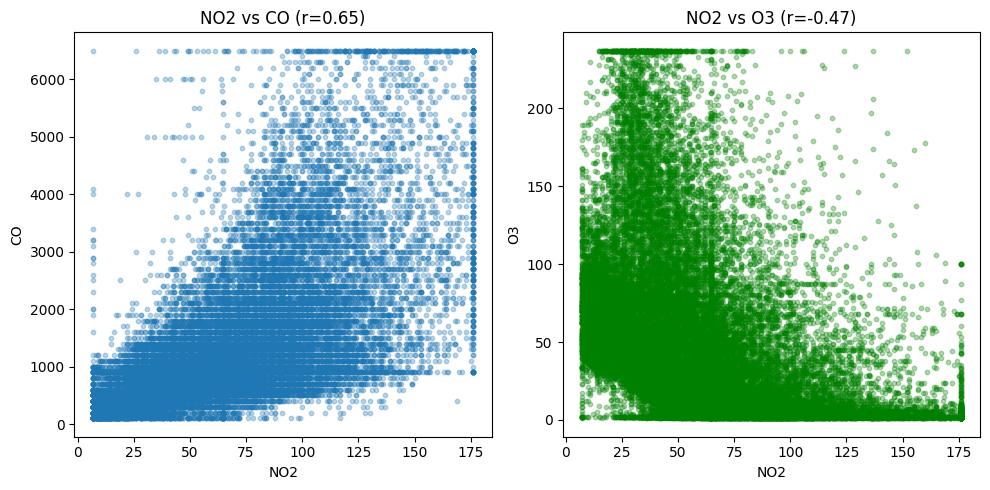

In [98]:
# 1. Scatter plot для самых коррелированных пар (NO2 vs CO)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(prsa_data['NO2'], prsa_data['CO'], alpha=0.3, s=10)
plt.xlabel('NO2')
plt.ylabel('CO')
plt.title('NO2 vs CO (r=0.65)')

# 2. NO2 vs O3 (отрицательная корреляция)
plt.subplot(1, 2, 2)
plt.scatter(prsa_data['NO2'], prsa_data['O3'], alpha=0.3, s=10, c='green')
plt.xlabel('NO2')
plt.ylabel('O3')
plt.title('NO2 vs O3 (r=-0.47)')

plt.tight_layout()
plt.show()

## Вывод по заданию 6 (визуализация связей между признаками)

- **NO2 vs CO:** На графике видна чёткая положительная линейная связь – с ростом NO2 увеличивается и CO. Это подтверждает высокую корреляцию (r = 0.65). Оба газа имеют общий источник – процессы горения (автомобили, заводы).

- **NO2 vs O3:** Наблюдается отрицательная связь: при высоких значениях NO2 концентрация O3 снижается. Это соответствует химии атмосферы: оксиды азота разрушают озон.

**Общий вывод:** Признаки NO2 и CO сильно взаимосвязаны (мультиколлинеарность), что нужно учитывать при выборе модели. O3 ведёт себя противоположно NO2, что делает его важным независимым предиктором.